# Inspect data products
What `heap.events.process_night()` writes (run by `process_pff.ipynb` or `pff_analysis.ipynb`), and how to load it
for further analysis:

```
<output_dir>/<YYYYMMDD>/<telescope>/
    processing.json              settings used
    <source>/<source>.npz        cleaned images + Hillas parameters, one row per frame
    <source>/calibrations.npz    pedestals, pedvars (per frame) and gain map (per night)
```

# Imports

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

from heap import diagnostics as dg
from heap import events as ev
from heap.config import load_analysis_config
from heap.parameterize import CAMERA_CMAP, TAB10_COLORS
from heap.process_dataset import slugify

# Globals

In [2]:
CONFIG = Path("../configs/crab.yaml") # relative to analysis_tools/
cfg = load_analysis_config(CONFIG)

RAW_DATA_DIR = cfg["paths"]["raw_data_dir"]
OUTPUT_DIR = cfg["paths"]["output_dir"]
SOURCE = cfg["source"]["name"]
TELESCOPES = [info["name"] for info in cfg["telescopes"].values()]
REFERENCE = cfg["events"]["reference"]
COINC_WINDOW = cfg["events"]["coinc_window"]
MIN_NPIX = cfg["cuts"]["min_npix"]
COLORS = {name: TAB10_COLORS[i] for i, name in enumerate(sorted(TELESCOPES))}

DATE = None # night to inspect; None = first night with SOURCE
TELESCOPE = REFERENCE # telescope to inspect

# Files
Every night, telescope and source in `OUTPUT_DIR` (see `heap.diagnostics.product_table()`).

In [3]:
products = dg.product_table(OUTPUT_DIR)
products.drop(columns="Settings")

,Date,Telescope,Source,Frames,Start,End,Hours,Rate,Cleaned,GainSource,MB
0,20260917,Fern,Crab,10528,2026-09-17 09:51:26+00:00,2026-09-17 12:06:08+00:00,2.25,1.30,0.863,flat,130.6
1,20260917,Gattini,Crab,10942,2026-09-17 09:51:24+00:00,2026-09-17 12:06:07+00:00,2.25,1.35,0.764,flat,135.8
2,20260917,Heli,Crab,11136,2026-09-17 09:51:24+00:00,2026-09-17 12:06:10+00:00,2.25,1.38,0.880,flat,138.2
3,20260917,Winter,Crab,13797,2026-09-17 09:51:23+00:00,2026-09-17 12:06:05+00:00,2.25,1.71,0.751,flat,171.2
4,20260918,Fern,Crab,11065,2026-09-18 10:54:59+00:00,2026-09-18 12:09:08+00:00,1.24,2.49,0.765,alt,137.3
5,20260918,Fern,MGRO_J2019_37,55937,2026-09-18 05:35:20+00:00,2026-09-18 08:26:25+00:00,2.85,5.45,0.345,alt,694.1
6,20260918,Gattini,Crab,11473,2026-09-18 10:54:21+00:00,2026-09-18 12:09:06+00:00,1.25,2.56,0.653,alt,142.4
7,20260918,Gattini,MGRO_J2019_37,58018,2026-09-18 05:35:21+00:00,2026-09-18 08:26:23+00:00,2.85,5.65,0.289,alt,719.9
8,20260918,Heli,Crab,11128,2026-09-18 10:55:16+00:00,2026-09-18 12:09:09+00:00,1.23,2.51,0.783,alt,138.1
9,20260918,Heli,MGRO_J2019_37,53297,2026-09-18 05:36:19+00:00,2026-09-18 08:26:27+00:00,2.84,5.22,0.378,alt,661.3


In [4]:
if DATE is None:
    DATE = products[products.Source == slugify(SOURCE, sep="_")].Date.iloc[0]
npz_path = ev.params_path(OUTPUT_DIR, DATE, TELESCOPE, SOURCE)
print(npz_path)
sorted(str(p.relative_to(OUTPUT_DIR)) for p in (OUTPUT_DIR / DATE / TELESCOPE).rglob("*"))

/home/nkorzoun/research/PANOSETI/data/processed/20260917/Winter/Crab/Crab.npz


['20260917/Winter/Crab',
 '20260917/Winter/Crab/Crab.npz',
 '20260917/Winter/Crab/calibrations.npz',
 '20260917/Winter/processing.json']

In [5]:
# settings the night was processed with; processing again with other settings needs REPROCESS or another output_dir
json.loads((OUTPUT_DIR / DATE / TELESCOPE / "processing.json").read_text())

{'data_product': 'dp_ph1024',
 'rate_cut': 10,
 'image_threshold': 4.0,
 'border_threshold': 2.0,
 'keep_brightest_island': True}

# Structure
Both npz files load as a `numpy.lib.npyio.NpzFile`: a read-only, dict-like map from key to numpy array (each array is
read from disk when its key is accessed). Every per-frame array has the same first axis `n`, frames in the same order
in both files, so row `i` of any key is the same frame.

In [6]:
npz = np.load(npz_path)
calib_npz = np.load(npz_path.parent / "calibrations.npz")
print(type(npz))
print(f"{npz_path.name}: {npz.files}")
print(f"calibrations.npz: {calib_npz.files}")

<class 'numpy.lib.npyio.NpzFile'>
Crab.npz: ['cleaned_images', 'N_pix', 'size', 'x_c', 'y_c', 's_xx', 's_yy', 's_xy', 'length', 'width', 'miss', 'distance', 'alpha', 'phi', 'Event', 'Timestamp']
calibrations.npz: ['pedestals', 'pedestal_variances', 'gain', 'gain_source', 'gain_caption']


In [7]:
dg.describe_npz(npz_path).style.format({"min": "{:.6g}", "max": "{:.6g}", "NaN": "{:.0f}"}, na_rep="")

,shape,dtype,min,max,NaN,description
key,,,,,,
cleaned_images,"(13797, 32, 32)",float32,0,2970.19,13946779,"(n, 32, 32) [frame, row, col]: (raw - pedestal) / gain, NaN where cleaning removed the pixel"
N_pix,"(13797,)",int64,0,750,0,"pixels left after cleaning (0 = nothing survived, Hillas parameters NaN)"
size,"(13797,)",float64,0,163509,0,"sum of the cleaned image (ADC, gain-corrected)"
x_c,"(13797,)",float64,-4.79531,4.79531,3439,"centroid x, along the columns (deg from camera center)"
y_c,"(13797,)",float64,-4.79531,4.79531,3439,"centroid y, along the rows (deg from camera center)"
s_xx,"(13797,)",float64,0,7.891,3439,second central moment in x (deg^2)
s_yy,"(13797,)",float64,0,7.52016,3439,second central moment in y (deg^2)
s_xy,"(13797,)",float64,-0.929207,0.913387,3439,second central moment in xy (deg^2)
length,"(13797,)",float64,0.0704809,2.82157,3439,rms spread along the image axis (deg)


In [8]:
dg.describe_npz(npz_path.parent / "calibrations.npz").style.format({"min": "{:.6g}", "max": "{:.6g}", "NaN": "{:.0f}"}, na_rep="")

,shape,dtype,value,min,max,NaN,description
key,,,,,,,
pedestals,"(13797, 1024)",float32,,-3.72635,18.5589,0,"(n, 1024) [frame, row*32 + col]: pedestal (ADC), constant within each 600 s window, 0 if never set"
pedestal_variances,"(13797, 1024)",float32,,0,28.6668,0,"(n, 1024) [frame, row*32 + col]: pedvar (ADC), the cleaning threshold unit, 0 if never set"
gain,"(32, 32)",float32,,1,1,0,"(32, 32) [row, col]: relative gain for the whole night, mean 1"
gain_source,(),<U4,flat,,,,"0-d string: which fallback made the gain map (own, alt, prior_night:, flat)"
gain_caption,(),<U66,Flat gain (1.0) — no usable frame pair this night or a prior night,,,,0-d string: the star fields the gain map came from


## One frame
Everything stored for one frame `i`. Images and the gain map are indexed `[row, col]` (row = y, col = x; plotted with
`origin="lower"`, and `extent=heap.parameterize.CAMERA_EXTENT` for degrees); pedestals and pedvars are flat per frame,
pixel `row*32 + col`. Hillas parameters are in degrees from the camera center (pixel `col` is at
`x = (col - 15.5) * PLATE_SCALE`, `PLATE_SCALE` = 0.309 deg/pixel).

In [9]:
i = int(np.flatnonzero(npz["N_pix"] >= 10)[0]) # first frame with at least 10 pixels left after cleaning
image = npz["cleaned_images"][i]
print(f"cleaned_images[{i}]: {type(image).__name__}, {image.dtype}, shape {image.shape}, {np.isfinite(image).sum()} finite pixels (. = NaN; row 0 printed first, so upside down relative to the plots)")
with np.printoptions(threshold=np.inf, linewidth=250, precision=0, suppress=True, nanstr="."):
    print(image)

cleaned_images[0]: ndarray, float32, shape (32, 32), 27 finite pixels (. = NaN; row 0 printed first, so upside down relative to the plots)
[[   .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .]
 [   .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .]
 [   .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .]
 [   .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .]
 [   .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .]
 [   .    .    .    .    .    .    .    .    .

In [10]:
# the same frame's Hillas parameters, one scalar per key
{key: npz[key][i].item() for key in npz.files if key != "cleaned_images"}

{'N_pix': 27,
 'size': 2646.3404116630554,
 'x_c': 0.6839200684306457,
 'y_c': 1.3258882349234125,
 's_xx': 0.15768353680393937,
 's_yy': 0.3204991086648558,
 's_xy': 0.16254221820247028,
 'length': 0.6487528128121133,
 'width': 0.23937926672367918,
 'miss': 0.11478340643906293,
 'distance': 1.4918868159181853,
 'alpha': 4.412607184295699,
 'phi': 58.30179042033894,
 'Event': 0,
 'Timestamp': 1789638683.859523}

In [11]:
# the same frame's calibrations, at its brightest pixel
row, col = np.unravel_index(np.nanargmax(image), image.shape)
pixel = row * 32 + col
print(f"cleaned_images[{i}][{row}, {col}] = {image[row, col]:.1f}")
print(f"pedestals[{i}][{pixel}] = {calib_npz['pedestals'][i][pixel]:.2f}   (= pedestals[{i}].reshape(32, 32)[{row}, {col}])")
print(f"pedestal_variances[{i}][{pixel}] = {calib_npz['pedestal_variances'][i][pixel]:.2f}")
print(f"gain[{row}, {col}] = {calib_npz['gain'][row, col]:.3f}")

cleaned_images[0][19, 17] = 382.5
pedestals[0][625] = 8.54   (= pedestals[0].reshape(32, 32)[19, 17])
pedestal_variances[0][625] = 19.27
gain[19, 17] = 1.000


In [12]:
# 0-d string arrays: .item() gives the str
print(repr(calib_npz["gain_source"]), "->", repr(calib_npz["gain_source"].item()))
print(repr(calib_npz["gain_caption"].item()))

array('flat', dtype='<U4') -> 'flat'
'Flat gain (1.0) — no usable frame pair this night or a prior night'


# Hillas parameters
`heap.diagnostics.load_products()` returns the Hillas parameters as a DataFrame,
the cleaned images and the calibrations, all one row per frame. Rows are every frame after the packet-loss and spike
cuts, in processing order (preflip runs, then postflip), not sorted by time; `Event` is the row index.

In [13]:
params, images, calib = dg.load_products(OUTPUT_DIR, DATE, TELESCOPE, SOURCE)
params.head()

,N_pix,size,x_c,y_c,s_xx,s_yy,s_xy,length,width,miss,distance,alpha,phi,Event,Timestamp
0,27,2646.340412,0.683920,1.325888,0.157684,0.320499,0.162542,0.648753,0.239379,0.114783,1.491887,4.412607,58.301790,0,1.789639e+09
1,8,898.749457,-4.187029,4.652402,0.046045,0.030065,0.002185,0.215265,0.172544,5.168282,6.259078,55.662152,187.648465,1,1.789639e+09
2,14,1678.773674,-2.727868,3.217626,0.059455,0.092223,0.011206,0.309336,0.236620,3.556758,4.218338,57.475928,72.814986,2,1.789639e+09
3,16,968.079840,-0.556744,-4.268275,0.075676,0.201733,-0.009715,0.449974,0.273737,0.881175,4.304432,11.812724,274.381155,3,1.789639e+09
4,28,2145.527838,-4.239961,0.257974,0.131912,0.320443,-0.135844,0.625719,0.246639,3.637144,4.247802,58.897150,117.621065,4,1.789639e+09


In [14]:
# load_products() returns the same arrays as a DataFrame + ndarray + NpzFile
print(type(params), type(images), images.shape, type(calib))
params.info()

<class 'pandas.core.frame.DataFrame'> <class 'numpy.ndarray'> (13797, 32, 32) <class 'numpy.lib.npyio.NpzFile'>
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13797 entries, 0 to 13796
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   N_pix      13797 non-null  int64  
 1   size       13797 non-null  float64
 2   x_c        10358 non-null  float64
 3   y_c        10358 non-null  float64
 4   s_xx       10358 non-null  float64
 5   s_yy       10358 non-null  float64
 6   s_xy       10358 non-null  float64
 7   length     10358 non-null  float64
 8   width      10358 non-null  float64
 9   miss       10358 non-null  float64
 10  distance   10358 non-null  float64
 11  alpha      10358 non-null  float64
 12  phi        10358 non-null  float64
 13  Event      13797 non-null  int64  
 14  Timestamp  13797 non-null  float64
dtypes: float64(13), int64(2)
memory usage: 1.6 MB


In [15]:
params.describe()

,N_pix,size,x_c,y_c,s_xx,s_yy,s_xy,length,width,miss,distance,alpha,phi,Event,Timestamp
count,13797.000000,13797.000000,10358.000000,10358.000000,10358.000000,10358.000000,10358.000000,10358.000000,10358.000000,10358.000000,10358.000000,10358.000000,10358.000000,13797.000000,1.379700e+04
mean,13.144089,1542.388483,-0.250916,-0.100964,0.134193,0.135831,0.001897,0.416208,0.214812,2.397739,3.821508,43.762259,179.908759,6898.000000,1.789644e+09
std,17.846925,4006.153209,2.887231,2.830635,0.189121,0.188620,0.091035,0.203714,0.095689,1.525124,1.347749,25.920833,101.555434,3982.995167,2.295569e+03
min,0.000000,0.000000,-4.795313,-4.795313,0.000000,0.000000,-0.929207,0.070481,0.000000,0.000000,0.085949,0.000000,0.000000,0.000000,1.789639e+09
25%,2.000000,52.679940,-2.883342,-2.581140,0.045017,0.045660,-0.021660,0.278794,0.159048,1.082658,2.922331,21.204536,91.164422,3449.000000,1.789642e+09
50%,9.000000,604.943500,-0.442297,-0.252028,0.085602,0.088293,0.000000,0.380138,0.217199,2.266523,4.011996,43.322405,181.537701,6898.000000,1.789645e+09
75%,18.000000,1497.154119,2.223533,2.270121,0.157508,0.160588,0.023523,0.504739,0.267215,3.604940,4.782255,65.984303,267.338477,10347.000000,1.789646e+09
max,750.000000,163508.870325,4.795313,4.795313,7.890999,7.520164,0.913387,2.821570,2.729452,6.593920,6.757579,89.989372,360.000000,13796.000000,1.789647e+09


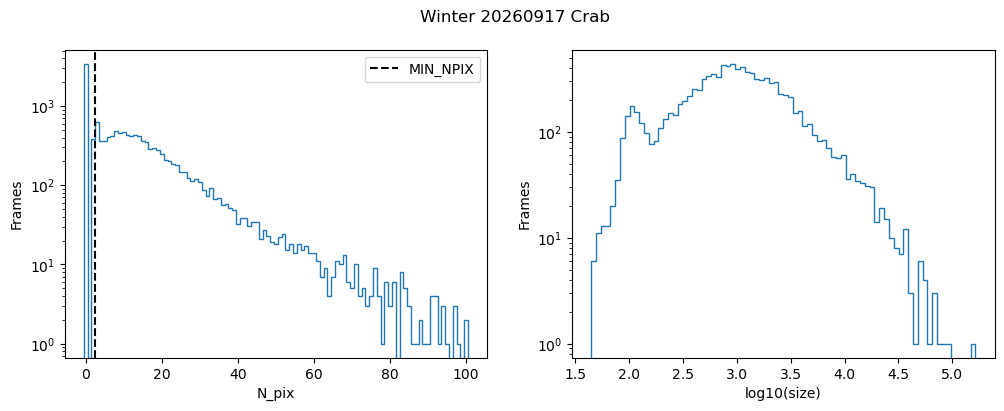

In [16]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].hist(params.N_pix, bins=np.arange(0, 102) - 0.5, histtype="step") # N_pix > 100 not shown
axs[0].axvline(MIN_NPIX - 0.5, color="k", ls="--", label="MIN_NPIX")
axs[0].set(yscale="log", xlabel="N_pix", ylabel="Frames")
axs[0].legend()
axs[1].hist(np.log10(params["size"][params.N_pix > 0]), bins=80, histtype="step")
axs[1].set(yscale="log", xlabel="log10(size)", ylabel="Frames")
fig.suptitle(f"{TELESCOPE} {DATE} {SOURCE}")
plt.show()

# Images
Cleaned images are pedestal-subtracted and gain-corrected, `(raw - pedestal) / gain`, with the pixels cleaning
removed set to NaN. Raw images aren't saved. Run the cell again for another random set.

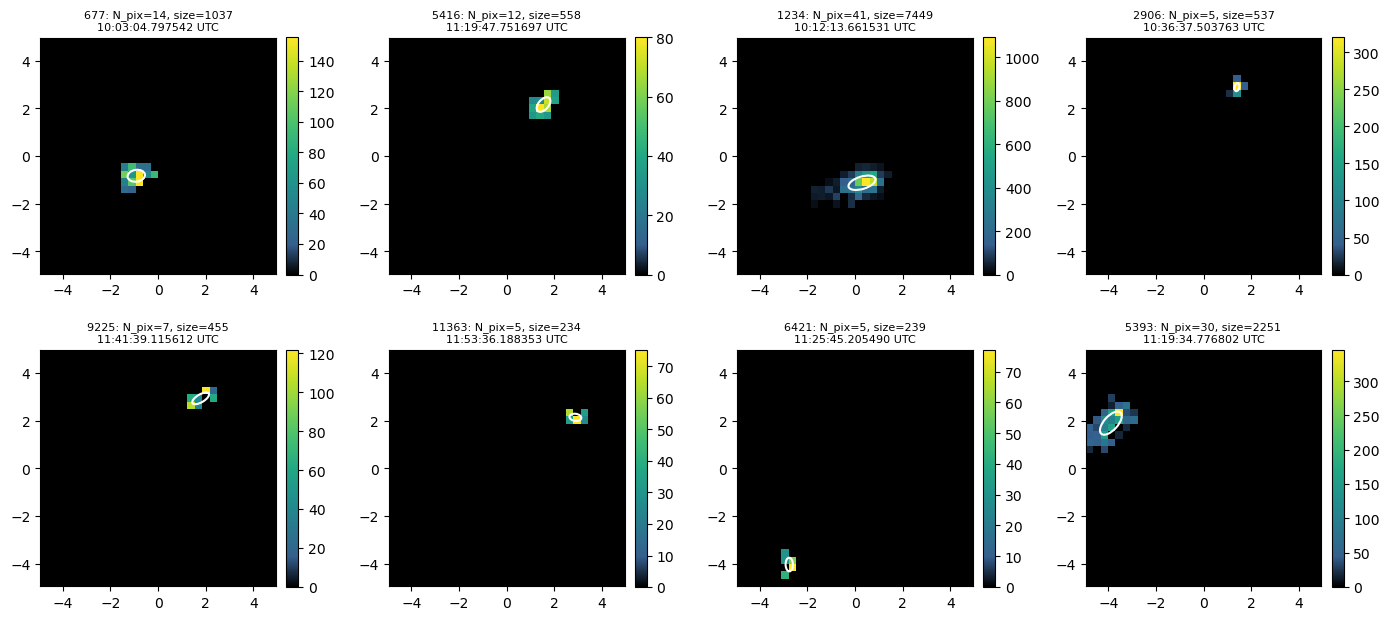

In [17]:
idx = np.random.default_rng().choice(np.flatnonzero(params.N_pix >= MIN_NPIX), size=8, replace=False)
dg.plot_image_grid(params, images, idx)
plt.show()

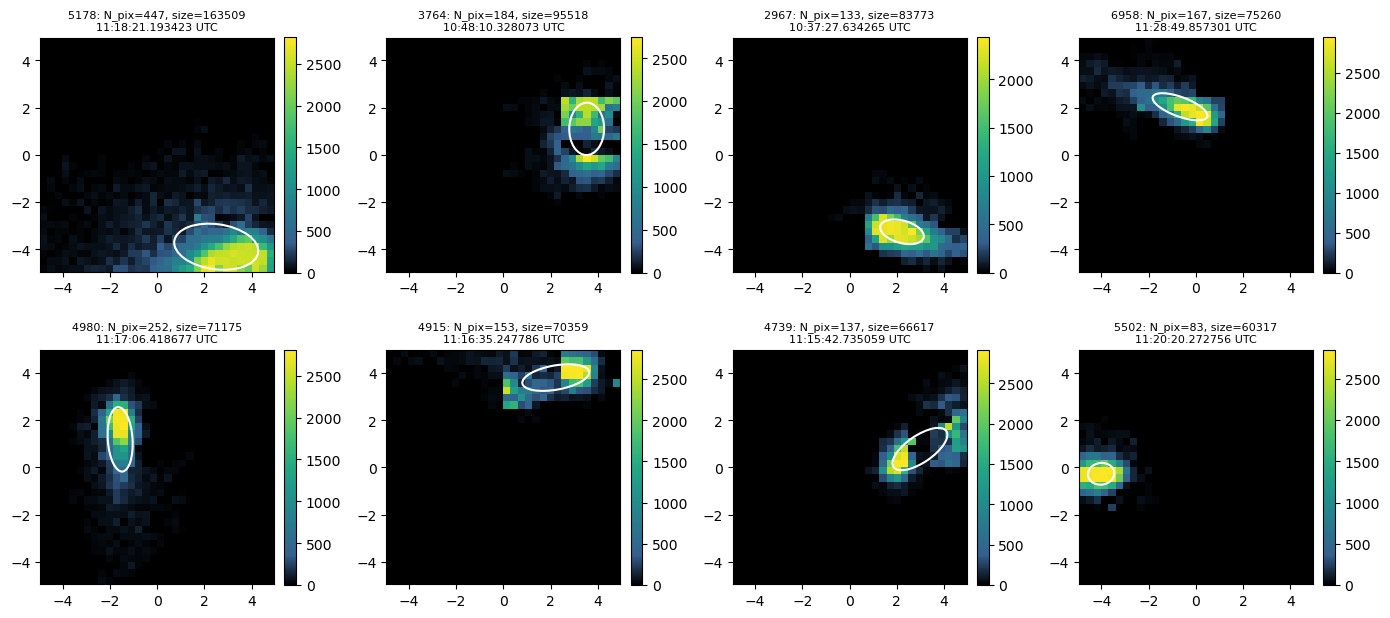

In [18]:
# brightest images
dg.plot_image_grid(params, images, params.nlargest(8, "size").index)
plt.show()

# Calibrations
`pedestals` and `pedestal_variances` are per frame (same rows as `params`, constant within each 600 s window); `gain`
is one (32, 32) map for the night, made as `gain_caption` says.

flat - Flat gain (1.0) — no usable frame pair this night or a prior night


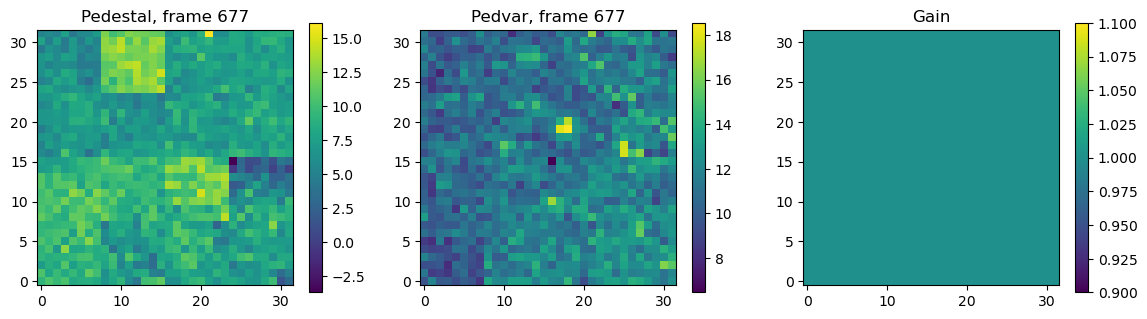

In [19]:
print(calib["gain_source"], "-", calib["gain_caption"])
i = idx[0]
fig, axs = plt.subplots(1, 3, figsize=(14, 3.5))
for ax, (values, label) in zip(axs, [(calib["pedestals"][i], "Pedestal"), (calib["pedestal_variances"][i], "Pedvar"), (calib["gain"], "Gain")]):
    fig.colorbar(ax.imshow(values.reshape(32, 32), origin="lower"), ax=ax)
    ax.set_title(f"{label}, frame {i}" if label != "Gain" else label)
plt.show()

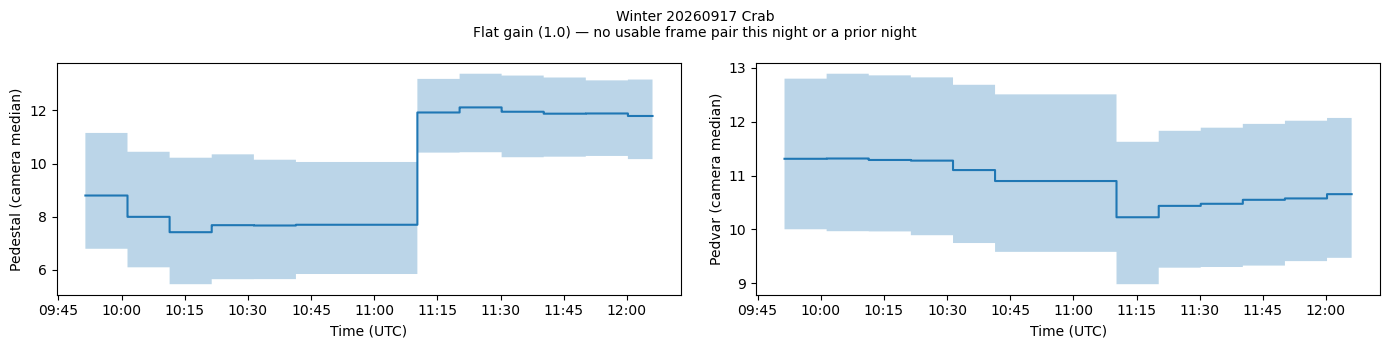

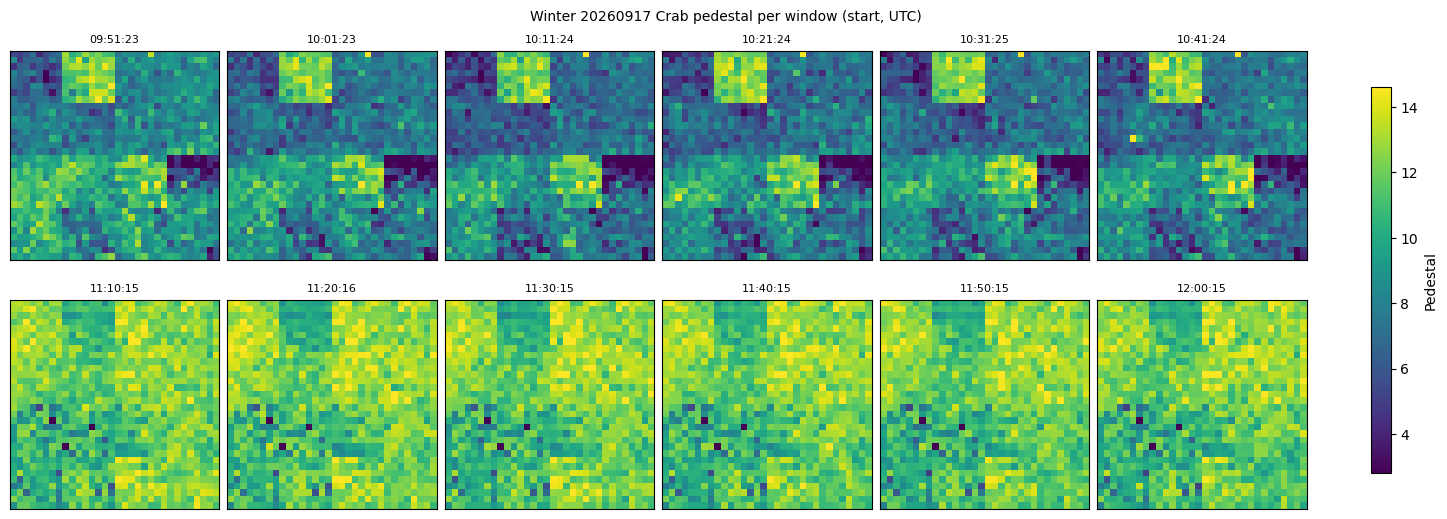

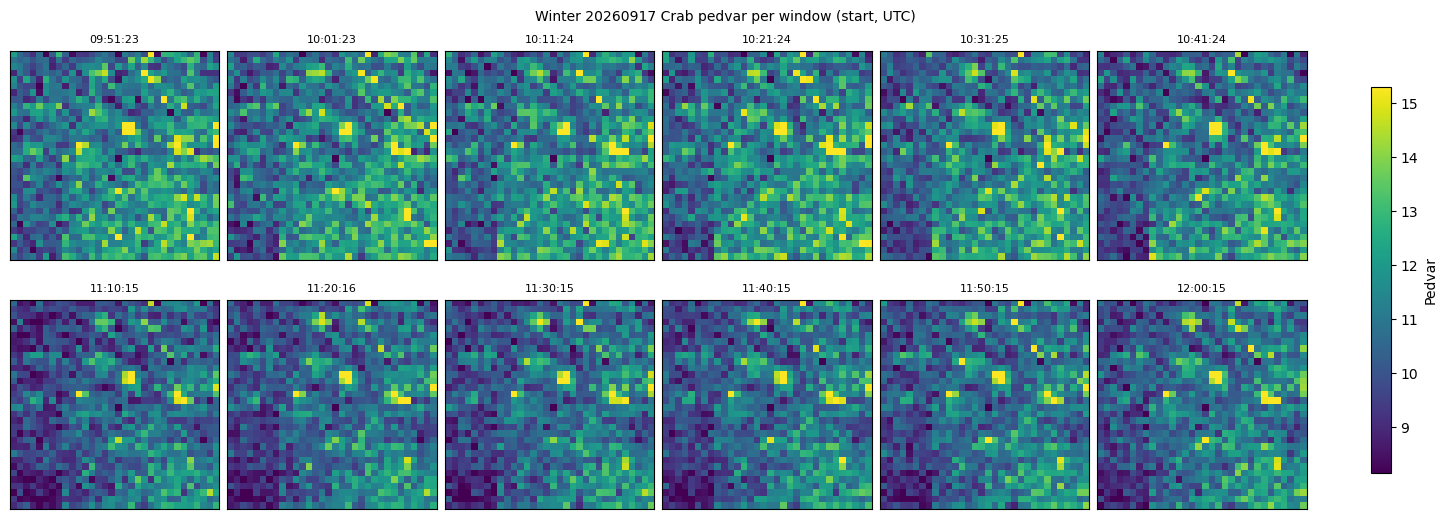

In [20]:
dg.plot_calibrations(params, calib, f"{TELESCOPE} {DATE} {SOURCE}")
dg.plot_calibration_windows(params, calib, f"{TELESCOPE} {DATE} {SOURCE}")
plt.show()

# Camera frame
`heap.events.load_camera_frame()` keeps the npz's Hillas columns, sorts by time, adds each frame's
flip side (from the raw `hk.pff`, so `RAW_DATA_DIR` is still needed) and rotates postflip images into the preflip frame.
`ImageIndex` is the row in `images`.

In [21]:
runs = ev.source_runs(RAW_DATA_DIR / DATE, TELESCOPE, SOURCE)
frame = ev.load_camera_frame(npz_path, TELESCOPE, runs)
frame.head()

,ImageIndex,Telescope,Timestamp,FlipSide,x_c,y_c,phi,size,N_pix,length,width,miss,distance,alpha
0,0,Winter,1.789639e+09,preflip,0.683920,1.325888,58.301790,2646.340412,27,0.648753,0.239379,0.114783,1.491887,4.412607
1,1,Winter,1.789639e+09,preflip,-4.187029,4.652402,187.648465,898.749457,8,0.215265,0.172544,5.168282,6.259078,55.662152
2,2,Winter,1.789639e+09,preflip,-2.727868,3.217626,72.814986,1678.773674,14,0.309336,0.236620,3.556758,4.218338,57.475928
3,3,Winter,1.789639e+09,preflip,-0.556744,-4.268275,274.381155,968.079840,16,0.449974,0.273737,0.881175,4.304432,11.812724
4,4,Winter,1.789639e+09,preflip,-4.239961,0.257974,117.621065,2145.527838,28,0.625719,0.246639,3.637144,4.247802,58.897150


In [22]:
frame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13797 entries, 0 to 13796
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ImageIndex  13797 non-null  int64  
 1   Telescope   13797 non-null  object 
 2   Timestamp   13797 non-null  float64
 3   FlipSide    13797 non-null  object 
 4   x_c         10358 non-null  float64
 5   y_c         10358 non-null  float64
 6   phi         10358 non-null  float64
 7   size        13797 non-null  float64
 8   N_pix       13797 non-null  int64  
 9   length      10358 non-null  float64
 10  width       10358 non-null  float64
 11  miss        10358 non-null  float64
 12  distance    10358 non-null  float64
 13  alpha       10358 non-null  float64
dtypes: float64(10), int64(2), object(2)
memory usage: 1.5+ MB


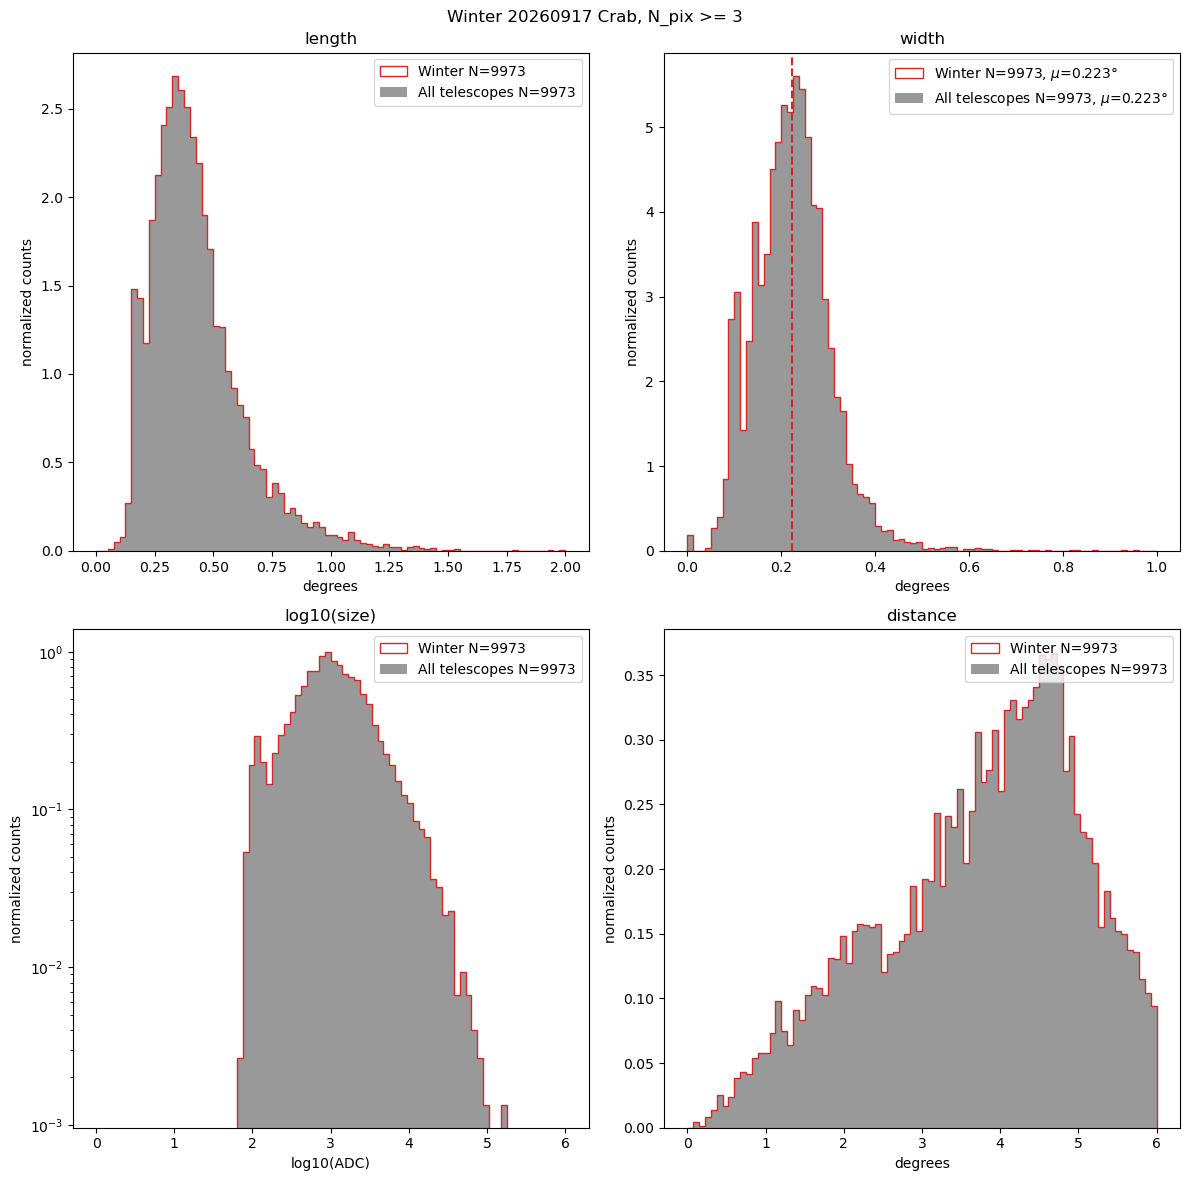

In [23]:
ev.plot_hillas(frame[frame.N_pix >= MIN_NPIX], f"{TELESCOPE} {DATE} {SOURCE}, N_pix >= {MIN_NPIX}", colors=COLORS)
plt.show()

# Array events
`heap.events.build_array_events()` does the above for every telescope, corrects timestamps against `REFERENCE` and
matches images within `COINC_WINDOW` into events, adding each event's `Date` and `Run`. This is `pff_analysis.ipynb`'s
starting point (its `df`), before any cuts.

In [24]:
events = ev.build_array_events(OUTPUT_DIR, RAW_DATA_DIR / DATE, DATE, SOURCE, TELESCOPES, REFERENCE, window=COINC_WINDOW)
events.head(10)

Winter-Heli timing offset: RMS=  0.00042 s, std= 0.00042 s
Winter-Heli corrected offset: RMS=  0.0 s, std= 0.0 s
Winter-Fern timing offset: RMS=  8e-05 s, std= 5e-05 s
Winter-Fern corrected offset: RMS=  0.0 s, std= 0.0 s
Winter-Gattini timing offset: RMS=  0.00106 s, std= 0.00104 s
Winter-Gattini corrected offset: RMS=  0.00131 s, std= 0.00128 s
Heli-Fern within 0.001s: 4293/11106 Heli events (38.7%) and 4290/10503 Fern events (40.8%) coincident, 4312 pairs
Heli-Winter within 0.001s: 3526/11106 Heli events (31.7%) and 3457/13797 Winter events (25.1%) coincident, 4193 pairs
Heli-Gattini within 0.001s: 517/11106 Heli events (4.7%) and 443/10912 Gattini events (4.1%) coincident, 554 pairs
Fern-Winter within 0.001s: 3144/10503 Fern events (29.9%) and 3144/13797 Winter events (22.8%) coincident, 3159 pairs
Fern-Gattini within 0.001s: 244/10503 Fern events (2.3%) and 244/10912 Gattini events (2.2%) coincident, 245 pairs
Winter-Gattini within 0.001s: 481/13797 Winter events (3.5%) and 460/10

/home/nkorzoun/.conda/envs/panoseti/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/nkorzoun/.conda/envs/panoseti/lib/python3.11/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/nkorzoun/.conda/envs/panoseti/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/nkorzoun/.conda/envs/panoseti/lib/python3.11/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/nkorzoun/.conda/envs/panoseti/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/nkorzoun/.conda/envs/panoseti/lib/python3.11/site-packag

,Event,Date,Run,ImageIndex,Telescope,Timestamp,FlipSide,x_c,y_c,phi,size,N_pix,length,width,miss,distance,alpha
0,0,20260917,obs_Palomar.start_2026-09-17T09:50:18Z.runtype...,0,Fern,1.789639e+09,preflip,-3.528994,3.916070,132.257750,1971.785771,20,0.402934,0.267899,0.021523,5.271565,0.233932
1,0,20260917,obs_Palomar.start_2026-09-17T09:50:18Z.runtype...,4,Heli,1.789639e+09,preflip,-3.069369,3.771221,150.508106,1768.235877,17,0.412835,0.211457,1.771515,4.862420,21.366218
2,0,20260917,obs_Palomar.start_2026-09-17T09:50:18Z.runtype...,2,Winter,1.789639e+09,preflip,-2.727868,3.217626,72.814986,1678.773674,14,0.309336,0.236620,3.556758,4.218338,57.475928
3,1,20260917,obs_Palomar.start_2026-09-17T09:50:18Z.runtype...,1,Fern,1.789639e+09,preflip,-1.304504,-4.288824,282.314280,1422.925868,18,0.564889,0.211591,2.189185,4.482828,29.232134
4,1,20260917,obs_Palomar.start_2026-09-17T09:50:18Z.runtype...,5,Heli,1.789639e+09,preflip,-1.138923,-4.394636,298.439435,2595.583038,25,0.516557,0.311247,3.094334,4.539821,42.968673
5,1,20260917,obs_Palomar.start_2026-09-17T09:50:18Z.runtype...,3,Winter,1.789639e+09,preflip,-0.556744,-4.268275,274.381155,968.079840,16,0.449974,0.273737,0.881175,4.304432,11.812724
6,2,20260917,obs_Palomar.start_2026-09-17T09:50:18Z.runtype...,3,Fern,1.789639e+09,preflip,1.477998,4.271825,100.223738,1050.117170,12,0.277336,0.221234,2.212748,4.520284,29.308724
7,2,20260917,obs_Palomar.start_2026-09-17T09:50:18Z.runtype...,3,Gattini,1.789639e+09,preflip,2.239513,2.224800,322.924796,3500.772818,24,0.321450,0.296901,3.125164,3.156763,81.886371
8,2,20260917,obs_Palomar.start_2026-09-17T09:50:18Z.runtype...,9,Heli,1.789639e+09,preflip,1.922405,4.081471,72.194495,2079.798561,19,0.401035,0.237327,0.582262,4.511546,7.415303
9,2,20260917,obs_Palomar.start_2026-09-17T09:50:18Z.runtype...,7,Winter,1.789639e+09,preflip,0.563832,3.486292,66.262341,1425.225209,18,0.504308,0.272832,0.887275,3.531591,14.550862


`events` is in long format: one row per telescope image, with `Event` grouping the images of one shower
(2+ telescopes). `ImageIndex` is the image's row in its own telescope's npz files.

In [25]:
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15176 entries, 0 to 15175
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Event       15176 non-null  int64  
 1   Date        15176 non-null  object 
 2   Run         15176 non-null  object 
 3   ImageIndex  15176 non-null  int64  
 4   Telescope   15176 non-null  object 
 5   Timestamp   15176 non-null  float64
 6   FlipSide    15176 non-null  object 
 7   x_c         15038 non-null  float64
 8   y_c         15038 non-null  float64
 9   phi         15038 non-null  float64
 10  size        15176 non-null  float64
 11  N_pix       15176 non-null  int64  
 12  length      15038 non-null  float64
 13  width       15038 non-null  float64
 14  miss        15038 non-null  float64
 15  distance    15038 non-null  float64
 16  alpha       15038 non-null  float64
dtypes: float64(10), int64(3), object(4)
memory usage: 2.0+ MB


In [26]:
e = events.Event.iloc[0]
event_rows = events[events.Event == e]
display(event_rows)
# each image back in its telescope's npz: same size as in the table (size may be divided by rel_tel_efficiency)
for _, image_row in event_rows.iterrows():
    tel_npz = np.load(ev.params_path(OUTPUT_DIR, DATE, image_row.Telescope, SOURCE))
    print(image_row.Telescope, image_row.ImageIndex, tel_npz["size"][image_row.ImageIndex], tel_npz["Timestamp"][image_row.ImageIndex])

,Event,Date,Run,ImageIndex,Telescope,Timestamp,FlipSide,x_c,y_c,phi,size,N_pix,length,width,miss,distance,alpha
0,0,20260917,obs_Palomar.start_2026-09-17T09:50:18Z.runtype...,0,Fern,1.789639e+09,preflip,-3.528994,3.916070,132.257750,1971.785771,20,0.402934,0.267899,0.021523,5.271565,0.233932
1,0,20260917,obs_Palomar.start_2026-09-17T09:50:18Z.runtype...,4,Heli,1.789639e+09,preflip,-3.069369,3.771221,150.508106,1768.235877,17,0.412835,0.211457,1.771515,4.862420,21.366218
2,0,20260917,obs_Palomar.start_2026-09-17T09:50:18Z.runtype...,2,Winter,1.789639e+09,preflip,-2.727868,3.217626,72.814986,1678.773674,14,0.309336,0.236620,3.556758,4.218338,57.475928


Fern 0 1971.785771369934 1789638686.190306
Heli 4 1768.2358770370483 1789638686.190149
Winter 2 1678.7736735343933 1789638686.19029


In [27]:
events.groupby("Event").Telescope.agg(lambda t: " + ".join(sorted(t))).value_counts()

Telescope
Fern + Heli + Winter              2165
Fern + Heli                       1860
Heli + Winter                      887
Fern + Winter                      731
Fern + Gattini + Heli + Winter     197
Gattini + Winter                   143
Gattini + Heli                     110
Gattini + Heli + Winter            106
Fern + Gattini                      22
Fern + Gattini + Heli               19
Fern + Gattini + Winter              4
Name: count, dtype: int64

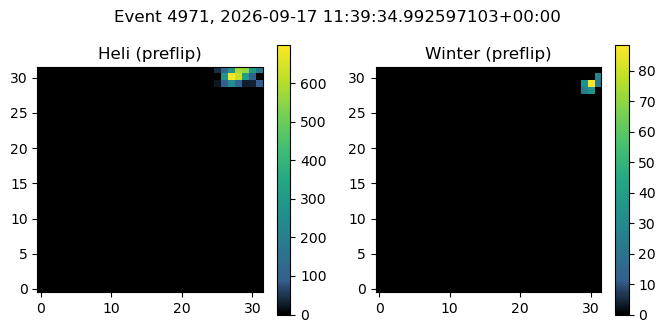

In [28]:
# one event's images, each from its own telescope's npz
event = events[events.Event == events.Event.sample(1).iloc[0]]
fig, axs = plt.subplots(1, len(event), figsize=(4*len(event), 3.5), squeeze=False)
for ax, (_, image) in zip(axs[0], event.iterrows()):
    tel_images = dg.load_products(OUTPUT_DIR, DATE, image.Telescope, SOURCE)[1]
    fig.colorbar(ax.imshow(tel_images[image.ImageIndex], origin="lower", cmap=CAMERA_CMAP, vmin=0), ax=ax)
    ax.set_title(f"{image.Telescope} ({image.FlipSide})")
fig.suptitle(f"Event {event.Event.iloc[0]}, {pd.to_datetime(event.Timestamp.min(), unit='s', utc=True)}")
plt.show()

To keep events (or `pff_analysis.ipynb`'s `array`/`directions`) for later, save them, e.g.
`events.to_csv(OUTPUT_DIR / DATE / "events.csv", index=False)`.